In [1]:
from matplotlib import pyplot as plt
import random
import pandas as pd

import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import jax
import jax.numpy as jnp
import arviz as az

from setup import DataGenerator
from parameters import Parameters

In [ ]:
opt = Parameters(True)
dg = DataGenerator(C=opt.C,
                   sig_y=opt.sig_y,
                   sig_w = opt.sig_w,
                   t_max=opt.t_max,
                   num_components=opt.num_components,
                   sparse_proportion=opt.sparse_proportion,
                   x_dim=opt.x_dim,
                   num_irr_dims=opt.num_irr_dims,
                   num_dense=opt.num_dense,
                   num_sparse=opt.num_sparse,
                   num_range=opt.num_range)

print('----Model Parameters-----')
print(f'C = {dg.C}')
print(f'w = {dg.w}')
print(f'sig_y = {dg.sig_y}')
df = pd.read_csv('datasets//data.csv')
df.head()

----Model Parameters-----
C = 100
w = [0.53147309 0.         0.12492089 0.76412915]
sig_y = 1.0


,ID,Code,x0,x1,x2,x3,obs,time
0,#K000000,0,0.65587,0.495894,0.125268,0.455214,4.748029,4.084084
1,#K000000,0,0.65587,0.495894,0.125268,0.455214,32.480668,1.611612
2,#K000000,0,0.65587,0.495894,0.125268,0.455214,1.405272,9.119119
3,#K000000,0,0.65587,0.495894,0.125268,0.455214,-0.121123,6.836837
4,#K000000,0,0.65587,0.495894,0.125268,0.455214,10.177209,3.213213


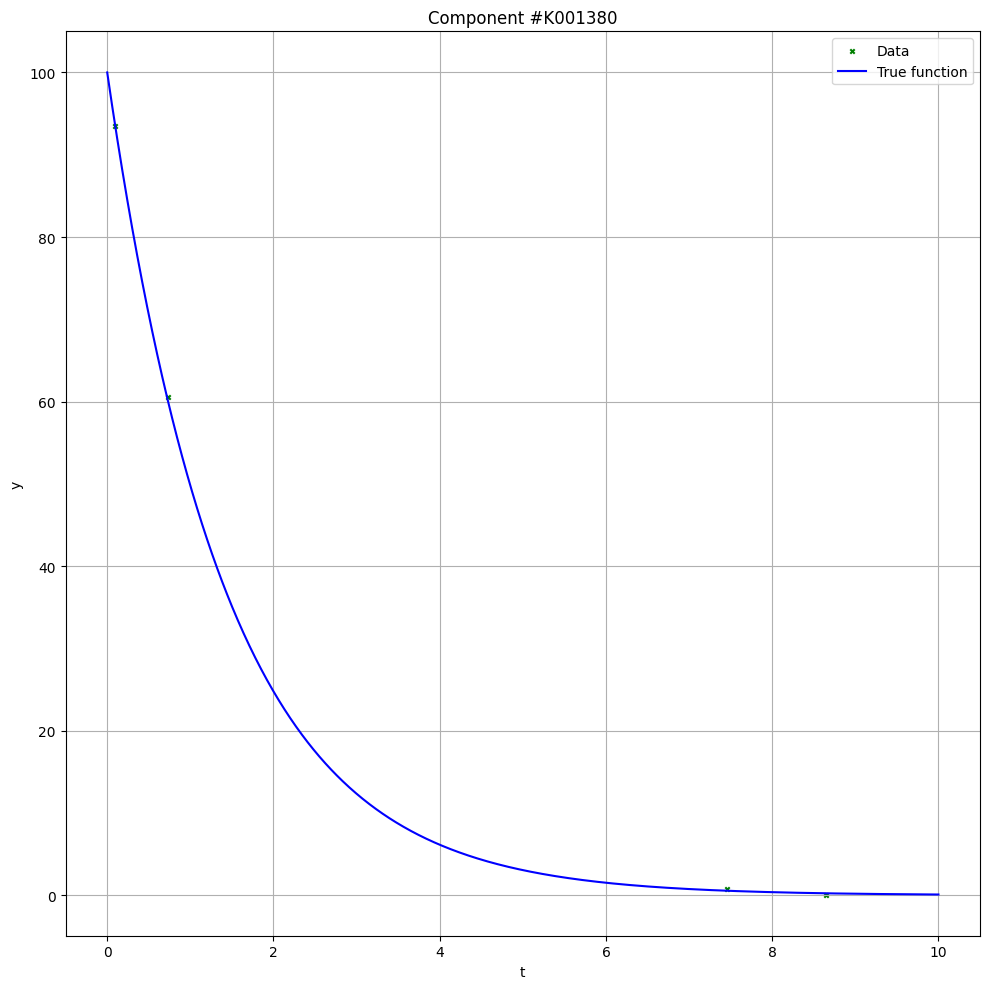

In [22]:
dg.plot_component(sparse=True)

In [23]:
def model(C,x_feats,t,y=None):

    mu_w = numpyro.sample('mu_w',dist.Normal(0.,5.))
    sig_w = numpyro.sample('sig_w',dist.HalfNormal(5.))
    
    with numpyro.plate('weights',x_feats.shape[1]):
        w = numpyro.sample('w',dist.Normal(mu_w,sig_w))
    
    y_est = C * jnp.exp(-t * (x_feats @ w))
    sig_y = numpyro.sample('sig_y',dist.HalfNormal(5.))

    with numpyro.plate('data',t.shape[0]):
        numpyro.sample('obs',dist.Normal(y_est,sig_y),obs=y)

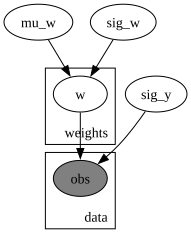

In [24]:
x = [f'x{i}' for i in range(opt.x_dim)]
x_feat = df[x].values
t = df['time'].values
y = df['obs'].values

numpyro.render_model(model,(opt.C,x_feat,t,y),render_params=True)

In [25]:
DEBUG = False
num_samples = 200 if DEBUG else 2000
num_warmup = 100 if DEBUG else 1000

seed = 0
nuts_kernel = NUTS(model)
mcmc = MCMC(nuts_kernel, num_samples=num_samples, num_warmup=num_warmup, num_chains=1,chain_method='vectorized')
rng_key = jax.random.PRNGKey(seed)
mcmc.run(rng_key, opt.C, x_feat, t, y=y)
mcmc.print_summary()

sample: 100%|██████████| 3000/3000 [00:54<00:00, 54.85it/s, 63 steps of size 4.23e-02. acc. prob=0.91] 


                mean       std    median      5.0%     95.0%     n_eff     r_hat
      mu_w      0.40      0.49      0.36     -0.29      1.07    246.45      1.01
     sig_w      0.75      0.69      0.54      0.18      1.37    233.06      1.00
     sig_y      1.00      0.00      1.00      0.99      1.01    641.90      1.00
      w[0]      0.53      0.00      0.53      0.53      0.53   2307.22      1.00
      w[1]      0.00      0.00      0.00     -0.00      0.00   2168.42      1.00
      w[2]      0.13      0.00      0.13      0.12      0.13   2190.02      1.00
      w[3]      0.76      0.00      0.76      0.76      0.76   2252.57      1.00

Number of divergences: 0


array([[<Axes: title={'center': 'mu_w'}>,
        <Axes: title={'center': 'mu_w'}>],
       [<Axes: title={'center': 'sig_w'}>,
        <Axes: title={'center': 'sig_w'}>],
       [<Axes: title={'center': 'sig_y'}>,
        <Axes: title={'center': 'sig_y'}>],
       [<Axes: title={'center': 'w'}>, <Axes: title={'center': 'w'}>]],
      dtype=object)

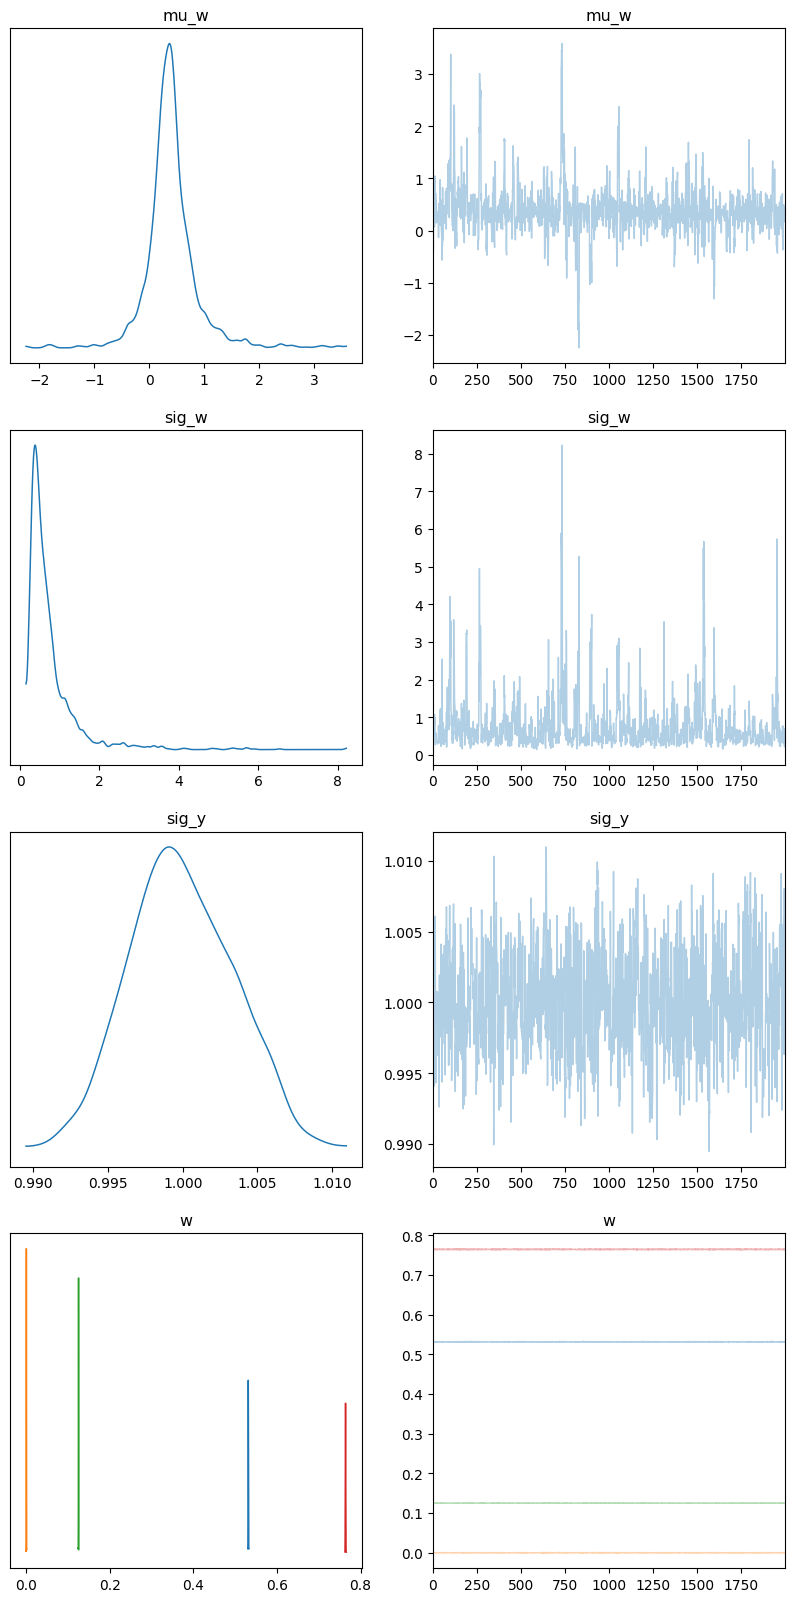

In [26]:
data = az.from_numpyro(mcmc)
az.plot_trace(data, compact=True, figsize=(10, 20))

In [27]:
samples = mcmc.get_samples()
w = samples['w']
w_est = w.mean(axis=0)
print(f'Predicted w: {w_est}')
print(f'Real w: {dg.w}')

Predicted w: [5.3138489e-01 1.5430263e-04 1.2505263e-01 7.6417005e-01]
Real w: [0.53147309 0.         0.12492089 0.76412915]


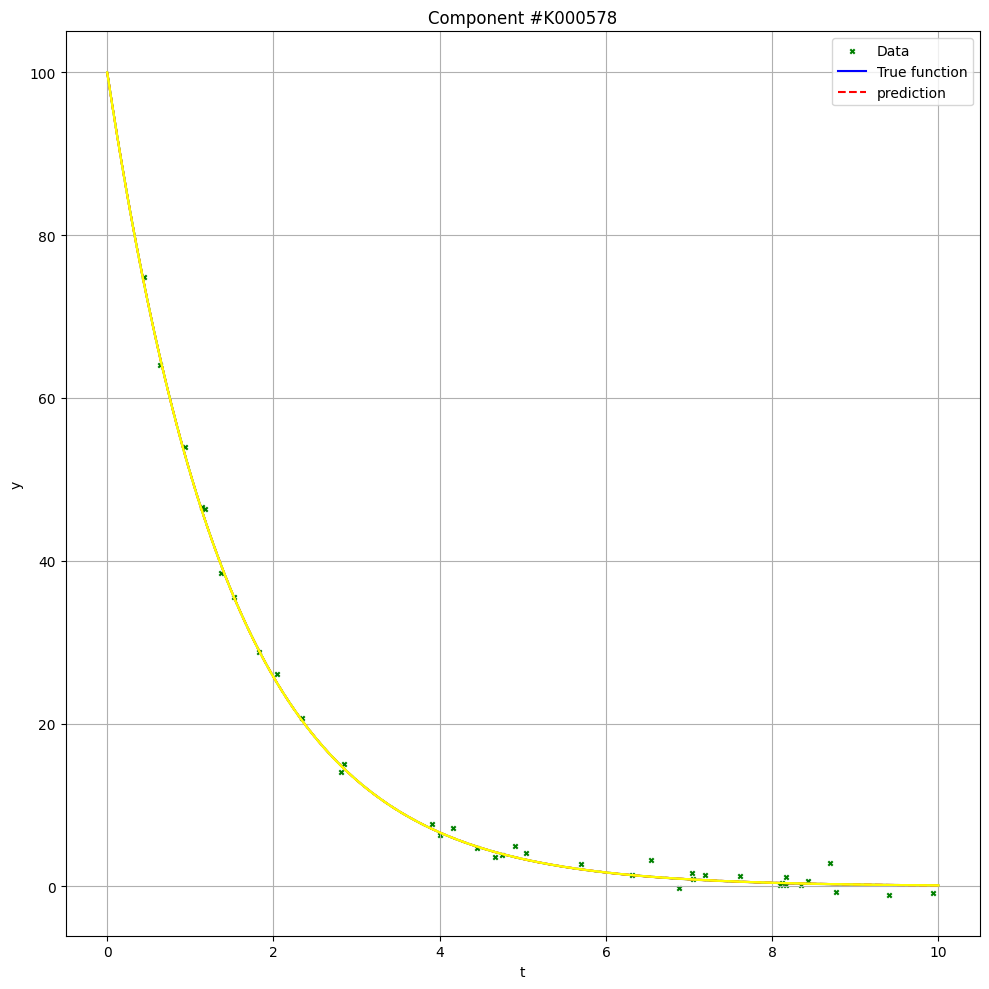

In [28]:
error_factor = 1.97
id , comp = dg.get_component(sparse=False)
x_comp = comp['x']

t_test = np.linspace(0,opt.t_max,1000)
y_test = opt.C * np.exp(-t_test[...,None] * (w @ x_comp))
y_est = y_test.mean(axis=1)
y_std = y_test.std(axis=1)
y_upper = y_est + error_factor * y_std
y_lower = y_est - error_factor * y_std

dg.plot_component(id,prediction=True)
plt.plot(t_test,y_est,linestyle='--',color='red',label='prediction')
plt.plot(t_test,y_upper,linestyle='-',color='yellow')
plt.plot(t_test,y_lower,linestyle='-',color='yellow')
plt.fill_between(t_test,y_lower,y_upper,color='olive',alpha=0.5)
plt.legend()

In [29]:
def relevance_model(C, x_feats, t, y=None):

    with numpyro.plate('weights',x_feats.shape[1]):
        mu_w = numpyro.sample('mu_w',dist.Normal(0.,5.))
        sig_w = numpyro.sample('sig_w',dist.HalfNormal(5.))
        w = numpyro.sample('w',dist.Normal(mu_w,sig_w))
    
    y_est = C * jnp.exp(-t * (x_feats @ w))
    sig_y = numpyro.sample('sig_y',dist.HalfNormal(5.))

    with numpyro.plate('data',t.shape[0]):
        numpyro.sample('obs',dist.Normal(y_est,sig_y),obs=y)

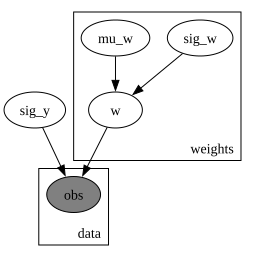

In [30]:
x = [f'x{i}' for i in range(opt.x_dim)]
x_feat = df[x].values
t = df['time'].values
y = df['obs'].values

numpyro.render_model(relevance_model,(opt.C,x_feat,t,y),render_params=True)

In [31]:
DEBUG = False
num_samples = 200 if DEBUG else 2000
num_warmup = 100 if DEBUG else 1000

seed = 0
nuts_kernel = NUTS(relevance_model)
mcmc = MCMC(nuts_kernel, num_samples=num_samples, num_warmup=num_warmup, num_chains=1,chain_method='vectorized')
rng_key = jax.random.PRNGKey(seed)
mcmc.run(rng_key, opt.C, x_feat, t, y=y)
mcmc.print_summary()

sample: 100%|██████████| 3000/3000 [02:13<00:00, 22.45it/s, 63 steps of size 3.51e-02. acc. prob=0.93] 


                mean       std    median      5.0%     95.0%     n_eff     r_hat
   mu_w[0]      0.39      2.90      0.48     -4.78      4.82    693.32      1.01
   mu_w[1]      0.18      2.67      0.07     -4.19      4.80    725.53      1.00
   mu_w[2]      0.08      2.72      0.12     -4.22      4.60    847.35      1.00
   mu_w[3]      0.74      2.57      0.79     -3.43      5.05    692.75      1.00
  sig_w[0]      3.57      2.67      3.02      0.05      7.28    705.41      1.00
  sig_w[1]      3.31      2.58      2.87      0.05      6.87    772.92      1.00
  sig_w[2]      3.38      2.66      2.73      0.07      7.10   1109.42      1.00
  sig_w[3]      3.25      2.57      2.68      0.05      6.76    918.07      1.00
     sig_y      1.00      0.00      1.00      0.99      1.01   1692.81      1.00
      w[0]      0.53      0.00      0.53      0.53      0.53   2206.12      1.00
      w[1]      0.00      0.00      0.00     -0.00      0.00   1864.09      1.00
      w[2]      0.13      0

array([[<Axes: title={'center': 'mu_w'}>,
        <Axes: title={'center': 'mu_w'}>],
       [<Axes: title={'center': 'sig_w'}>,
        <Axes: title={'center': 'sig_w'}>],
       [<Axes: title={'center': 'sig_y'}>,
        <Axes: title={'center': 'sig_y'}>],
       [<Axes: title={'center': 'w'}>, <Axes: title={'center': 'w'}>]],
      dtype=object)

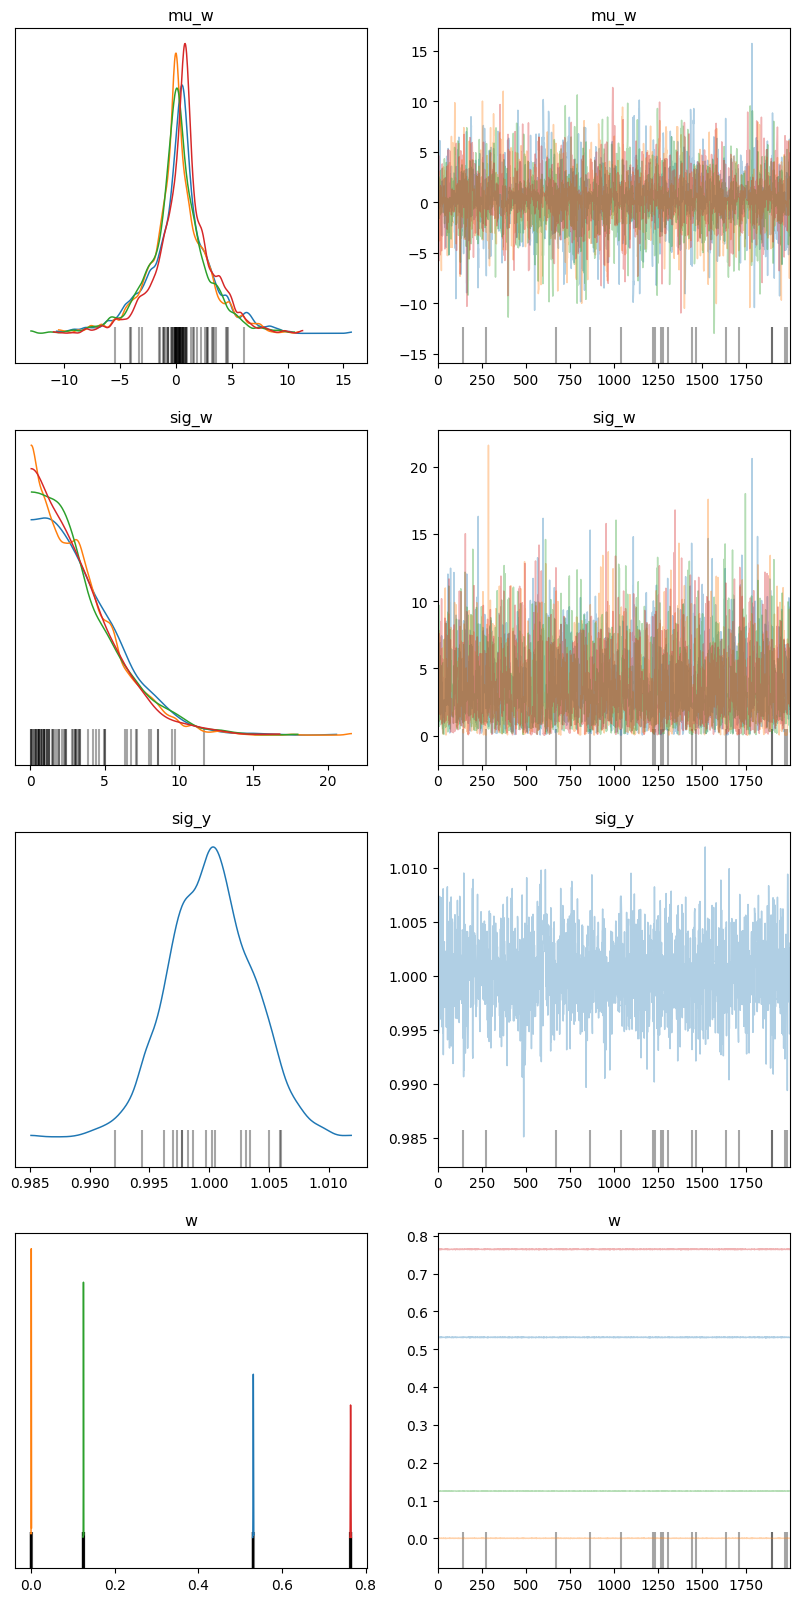

In [32]:
data = az.from_numpyro(mcmc)
az.plot_trace(data, compact=True, figsize=(10, 20))